In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', None)

# Part 1: Understanding Product Categories

In [2]:
data = pd.read_csv("amz_uk_price_prediction_dataset.csv")
data.head()
df = data.copy()

In [3]:
df.shape

(2443651, 9)

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [6]:
round(df.describe(), 2)

,uid,stars,reviews,price,boughtInLastMonth
count,2443651.00,2443651.00,2443651.00,2443651.00,2443651.00
mean,1370545.35,2.15,480.63,89.24,25.90
std,816056.17,2.19,5944.12,345.61,240.48
min,1.00,0.00,0.00,0.00,0.00
25%,658921.50,0.00,0.00,9.99,0.00
50%,1349029.00,0.00,0.00,19.09,0.00
75%,2060685.50,4.40,59.00,45.99,0.00
max,2828593.00,5.00,1356658.00,100000.00,50000.00


In [7]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# 1. Frequency Tables

cat = df.select_dtypes(exclude = 'number')
num = df.select_dtypes(include = 'number')

In [10]:
cat

,asin,title,isBestSeller,category
0,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",False,Hi-Fi Speakers
1,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",True,Hi-Fi Speakers
2,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",False,Hi-Fi Speakers
3,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",False,Hi-Fi Speakers
4,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,False,Hi-Fi Speakers
...,...,...,...,...
2443646,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",False,Motorbike Clothing
2443647,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,False,Motorbike Clothing
2443648,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,False,Motorbike Clothing
2443649,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,False,Motorbike Clothing


In [11]:
num

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0
...,...,...,...,...,...
2443646,2828589,0.0,0,22.34,0
2443647,2828590,0.0,0,97.99,0
2443648,2828591,0.0,0,52.99,0
2443649,2828592,4.3,404,79.99,0


In [12]:
top_five_listed_cat = cat['category'].value_counts().head(5) #value_counts() already sorts in descending order by default
print(top_five_listed_cat)
print("\n",top_five_listed_cat.index)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

 Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts'],
      dtype='object', name='category')


In [13]:
type(top_five_listed_cat)

pandas.core.series.Series

In [14]:
display(len(top_five_listed_cat))

5

In [15]:
# To convert Series to DataFrame
# df_top_five = top_five_listed_cat.reset_index()

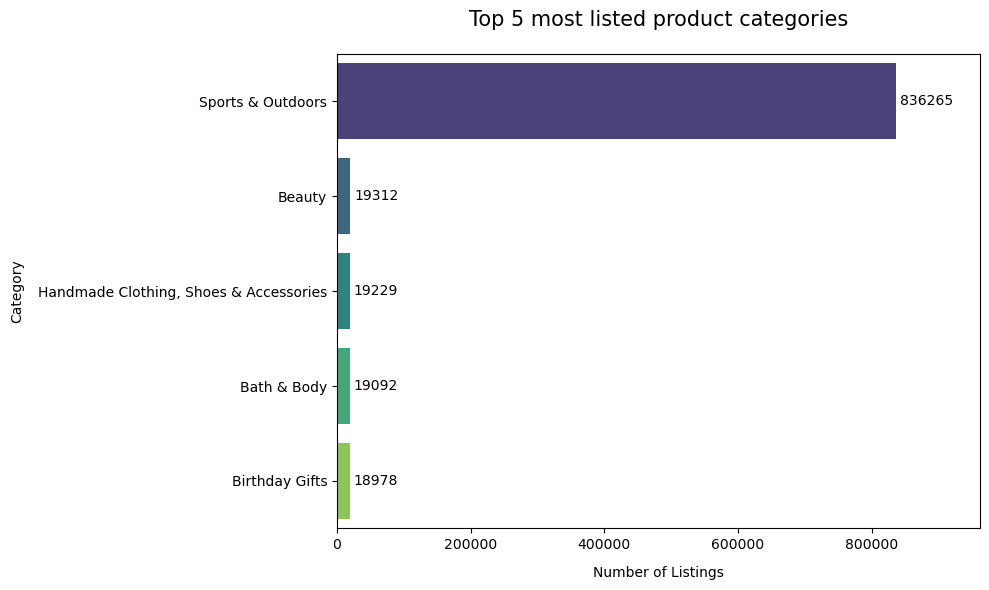

In [ ]:
# 2. Visualizations

plt.figure(figsize = (10,6))
ax = sns.barplot(
    #data=top_five_listed, # Since type(top_five_listed_cat) gives a Series (which was created by the line top_five_listed_cat = cat['category'].value_counts().head(5)), then the arrays are passed directly. data= paramter is used with a DataFrame containing columns x and y not a Series
    x = top_five_listed_cat.values, # x = 'count' if data=top_five_listed is used
    y = top_five_listed_cat.index, # y = 'category' if data=top_five_listed is used
    hue = top_five_listed_cat.index, # hue = 'category' if data=top_five_listed is used
    legend = False, #prevents a reduncant legend from popping up
    palette = 'viridis'
    )


ax.set_title("Top 5 most listed product categories", fontsize = 15, pad = 20)
#ax.set_xticks(rotation = 90)
#ax.set_legend()
# Find the max value in the data and multiply by 1.15 to add 15% extra space
max_val = top_five_listed_cat.max()
ax.set_xlim(0, max_val * 1.15)
ax.set_xlabel("Number of Listings", labelpad = 10)
ax.set_ylabel("Category", labelpad = 10)

#plt.bar_label(plt.gca().containers[0], padding=3) #This add the value of only the first category "Sports & Outdoors"
#When hue paramter in Searborn was used, matplotlib created a new container for every single color. If hue and palette parameters are removed from the code, then there will be only one contained, then we won't need a for loop.
#plt.gca() is a way of "finding" the chart if there is no name for it. Here the chart is called ax (ax = sns.barplot)
#Loop through all containers and add labels to each
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

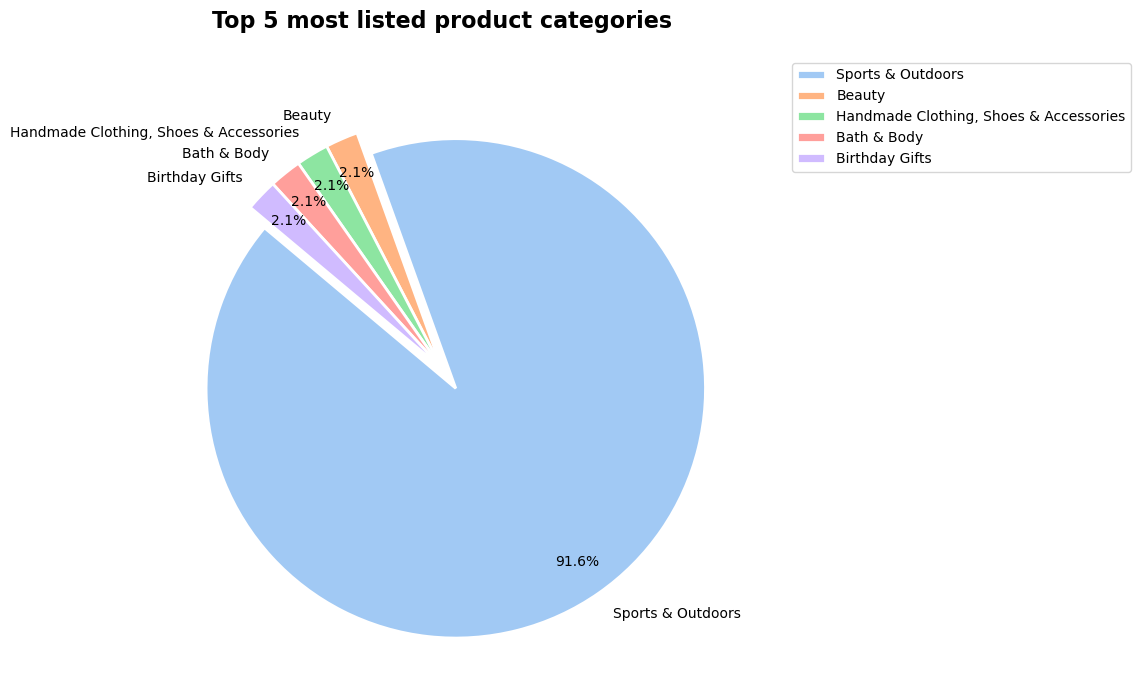

In [17]:
plt.figure(figsize=(10,7))

explode = [0.1 if i == 0 else 0 for i in range(len(top_five_listed_cat))]
top_five_listed_cat.plot.pie(autopct='%1.1f%%', startangle = 140, colors= sns.color_palette('pastel'), wedgeprops = {'edgecolor':'white', 'linewidth':2}, explode=explode, pctdistance=0.85, labeldistance=1.1)
plt.title("Top 5 most listed product categories", fontsize = 16, fontweight = 'bold', pad=20)
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad = 0.5)
plt.tight_layout()
plt.show()
#The category "Sports & Outdoors" dominates the listings

Part 1 Analysis: Understanding Product Categories

Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. Key Findings: A Monopolistic Market Structure

The distribution of product listings on Amazon UK (within this dataset) is characterized by a "Winner-Take-All" dynamic.

    Absolute Dominance: The "Sports & Outdoors" category is the overwhelming market leader, accounting for 91.6% of all listings. It is not merely the most popular category; it defines almost the entire dataset.

    The "Flat" Runner-ups: In contrast, the next four categories—Beauty, Handmade Clothing, Bath & Body, and Birthday Gifts are tied for a distant second place, each representing only 2.1% of listings.

2. Comparison of Listing Frequency

The comparison shows a steep drop-off rather than a traditional competitive curve.

    Lack of Graduation: In most diverse marketplaces, we expect a "staircase" decline (e.g., 40%, 25%, 15%). Here, we see a "cliff." This indicates that there is no mid-tier competition; a product is either in the dominant category or in a micro-niche.

    Fragmented Secondary Market: Outside of the leader, the market is completely fragmented. Since the four runner-ups have identical frequencies, there is no clear "secondary" market leader to indicate a strong alternative consumer trend.

3. Business Implications

    Dataset Specialization: Such extreme concentration suggests this dataset may be a specialized extract focused on sporting goods, rather than a general cross-section of all Amazon UK activity.

    Market Entry Risk: For a business, this implies that "Sports & Outdoors" is a high-saturation environment. While it has the most traffic (listings), it also carries the highest competition. Conversely, the 2.1% categories represent "Blue Ocean" opportunities with far less competition, though likely with much lower total search volume.

# Part 2: Delving into Product Pricing

In [ ]:
# 1. Measures of Centrality

prices = num['price']

mean_prices = prices.mean()
print(f"Mean of the price of products: £{mean_prices:.2f}")
median_prices = prices.median()
print(f"\nMedian of the price of products: £{median_prices:.2f}")
mode_prices = prices.mode()
print(f"\nMode of the price of products: £{mode_prices[0]:.2f}")

Mean of the price of products: £89.24

Median of the price of products: £19.09

Mode of the price of products: £9.99


In [19]:
#The average price point of products listed is 89. It is around 9x times more than the mode.

In [ ]:
# 2. Measures of Dispersion

variance_prices = prices.var()
print(f"Variance of the price of products: {variance_prices:.2f}")
std_prices = prices.std()
print(f"\nStandard deviation of the price of products: £{std_prices:.2f}")
max_price = prices.max()
min_price = prices.min()
range_prices = max_price - min_price
print(f"\nMaximum price: £{max_price}")
print(f"\nMinimum price: £{min_price}")
print(f"\nRange: £{range_prices:.2f}")
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3-Q1
print(f"\nQ1 for product price: £{Q1:.2f}")
print(f"\nQ3 for product price: £{Q3:.2f}")
print(f"\nInterquantile range for product price: £{IQR:.2f}")

Variance of the price of products: 119445.49

Standard deviation of the price of products: £345.61

Maximum price: £100000.0

Minimum price: £0.0

Range: £100000.00

Q1 for product price: £9.99

Q3 for product price: £45.99

Interquantile range for product price: £36.00


In [21]:
#The product prices are extremely varied since the standard deviation and the variance are very high. Also, the range is extremely high. The values of these parameters are indicators of a significant spread in prices.

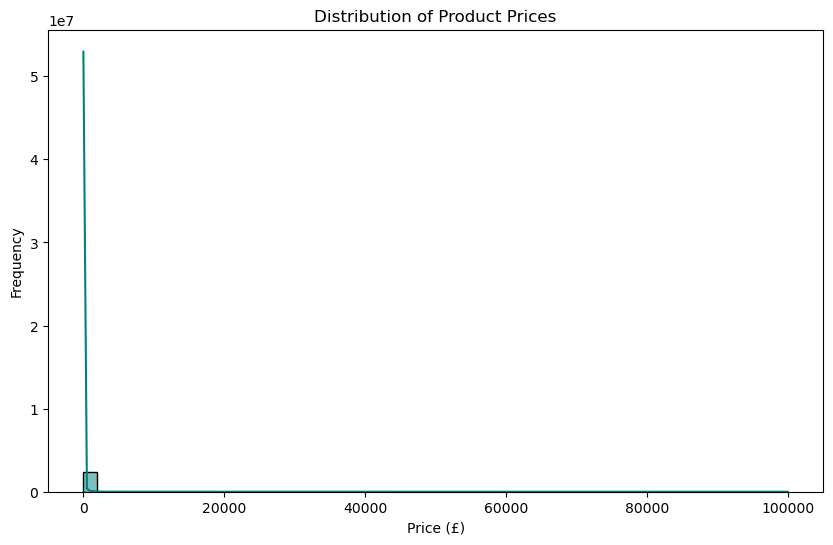

In [ ]:
# 3. Visualizations

plt.figure(figsize = (10, 6))

sns.histplot(
    prices,
    bins = 50,
    kde=True,
    color='teal'
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

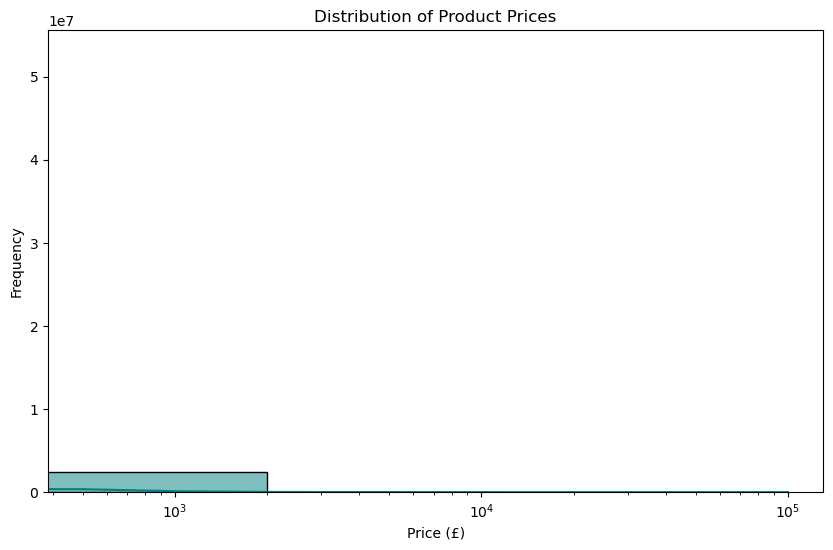

In [44]:
plt.figure(figsize = (10, 6))

sns.histplot(
    prices,
    bins = 50,
    kde=True,
    color='teal'
)

plt.xscale('log')
plt.title("Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

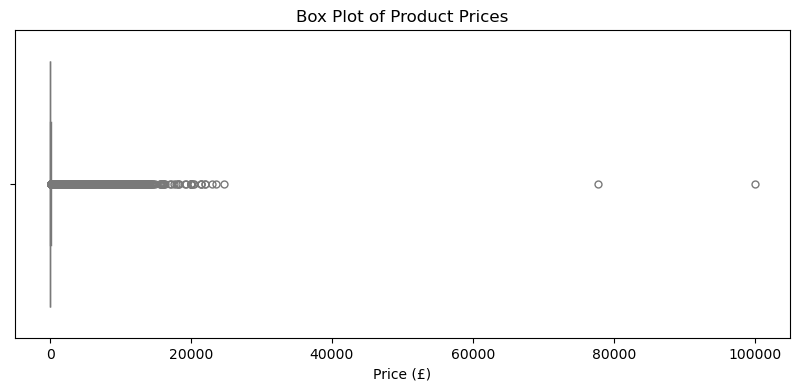

In [53]:
plt.figure(figsize=(10, 4))

sns.boxplot(x = prices, color='lightblue', fliersize = 5)
plt.title("Box Plot of Product Prices")
plt.xlabel("Price (£)")
plt.show()

Part 2: Delving into Product Pricing
#### Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. Central Tendency & Market Reality

While the mean of products is £89.24, this figure is heavily inflated by extreme luxury items. The Median price of £19.09 serves as a much more accurate representative of the typical customer experience. Because the mean is nearly 4.5 times higher than the Median, the pricing distribution is highly right-skewed, indicating a marketplace dominated by affordable goods with a "thin tail" of ultra-premium products.

2. Most Common Price Points & Competitive Zones

    Psychological Pricing: The Mode is £9.99, confirming that sellers lean heavily on "charm pricing" to attract budget-conscious shoppers.

    The "Volume" Zone: The middle 50% of the market (the IQR) sits between £9.99 (Q1) and £45.99 (Q3). For a new business, this range represents the "competitive heart" of Amazon UK, where the highest volume of transactions and listings occurs.

3. Price Volatility & The Outlier Effect

The market displays extreme dispersion. A Standard Deviation of £345.61 (which is massive compared to the median) and a total Range of £100,000 highlight an incredible diversity in inventory. However, the Box Plot reveals that the vast majority of this £100,000 span is occupied by statistical outliers. These aren't "typical" products but rather extreme high-ticket specialty items.

4. Visual Distribution Insights

    Histogram: The sharp peak in the £0–£50 range confirms that Amazon UK is primarily a high-volume, low-to-mid-cost marketplace.

    Box Plot: The "long tail" of outliers stretching toward the £100,000 mark visually confirms that while the "bulk" of the business is in affordable items, the platform successfully hosts a significant luxury or industrial niche.

5. Cross-Category Synthesis (The "Big Insight")

When we combine these findings with Part 1, we get the full picture: The 91.6% dominance of 'Sports & Outdoors' means that the common price points (£9.99 to £19.09) are specifically defining the sporting goods market.

Conversely, the extreme outliers (reaching up to £100,000) likely belong to the smaller 2.1% categories. For example, 'Birthday Gifts' or 'Handmade' items might include high-value bespoke jewelry or specialty collectibles that exist in much lower quantities but at vastly higher price points than a standard piece of sports equipment.

# Part 3: Unpacking Product Ratings

In [ ]:
# 1. Measures of Centrality
rating = num['stars']
rating

0          4.7
1          4.7
2          4.7
3          4.7
4          4.6
          ... 
2443646    0.0
2443647    0.0
2443648    0.0
2443649    4.3
2443650    4.5
Name: stars, Length: 2443651, dtype: float64

In [68]:
rating_mean = rating.mean()
print(f"Mean of ratings: {rating_mean:.2f}")
rating_median = rating.median()
print(f"Median of ratings: {rating_median:.2f}")
rating_mode = rating.mode()[0]
print(f"Mode of ratings: {rating_mode:.2f}")

Mean of ratings: 2.15
Median of ratings: 0.00
Mode of ratings: 0.00


In [69]:
unrated_pct = (num['stars'] == 0).mean() * 100
print(f"{unrated_pct:.1f}% of products have 0 stars.")

50.2% of products have 0 stars.


In [75]:
rated_products = num[num['stars'] > 0]['stars']
#rated_products = num.query('stars > 0')['stars']
rated_products_mean = rated_products.mean()
print(f"Mean (rated only): {rated_products_mean:.2f}")
rated_products_median = rated_products.median()
print(f"Median (rated only): {rated_products_median:.2f}")
rated_products_mode = rated_products.mode()[0]
print(f"Mode (rated only): {rated_products_mode:.2f}")

Mean (rated only): 4.32
Median (rated only): 4.40
Mode (rated only): 4.50


The "Zero-Inflation" Discovery and its Impact

A primary analysis of the dataset revealed a Mean rating of 2.15, while both the Median and Mode sat at 0.00. These unusual figures point to a Zero-Inflated Distribution, where 50.2% of all products have no recorded rating. In the context of Amazon UK, a 0.0-star rating typically signifies a new listing or an item that has yet to gain consumer traction. Consequently, the overall average of 2.15 is mathematically accurate but practically misleading, as it is heavily suppressed by this unrated majority.
Subset Analysis: The "Rated Only" Reality

To uncover the true sentiment of engaged customers, a subset analysis was performed by filtering out the unrated (0.0) items. This revealed a starkly different and highly positive landscape:

Metric  |   All Products (Included 0.0) --> Rated Products Only (> 0.0)

Mean    |   2.15 --> 4.32

Median  |   0.00 --> 4.40

Mode    |   0.00 --> 4.50

A Polarized "U-Shaped" Trend

The rating distribution follows a Bimodal (U-shaped) trend, indicating that the "average" 2- or 3-star product rarely exists in this dataset. Instead, products fall into two distinct camps:

    Group A (The "Starting Gate"): The unrated majority (50.2%) waiting for initial consumer engagement.

    Group B (The "High-Performers"): Successfully rated products that sit almost exclusively in the 4.0 to 5.0-star range.

Strategic Business Insight: The Social Proof Hurdle

The data suggests that the primary challenge for Amazon UK sellers in this dataset is not product quality, but rather a significant "Social Proof Hurdle." Once a product clears the initial barrier of receiving its first review, it tends to jump immediately to high satisfaction levels (Mode: 4.50).

Conclusion: Customer sentiment is excellent once visibility is achieved. From a business perspective, the focus should shift from quality control to Social Proof Conversion - implementing strategies to move the 50.2% of unrated products into the "High-Performer" category to build buyer trust and accelerate sales.

In [81]:
# 2. Measures of Dispersion

rating_var = rating.var()
print(f"Variance of ratings: {rating_var:.2f}")
rating_std = rating.std()
print(f"Standard deviation of ratings: {rating_std:.2f}")
rating_Q1 = rating.quantile(0.25)
rating_Q3 = rating.quantile(0.75)
rating_IQR = rating_Q3 - rating_Q1
print(f"Interquartile range: {rating_IQR:.2f}")

Variance of ratings: 4.82
Standard deviation of ratings: 2.19
Interquartile range: 4.40


In [83]:
rated_products_var = rated_products.var()
print(f"Variance (rated only): {rated_products_var:.2f}")
rated_products_std = rated_products.std()
print(f"Standard deviation (rated only): {rated_products_std:.2f}")
rated_products_Q1 = rated_products.quantile(0.25)
rated_products_Q3 = rated_products.quantile(0.75)
rated_products_IQR = rated_products_Q3 - rated_products_Q1
print(f"Interquartile range (rated only): {rated_products_IQR:.2f}")

Variance (rated only): 0.31
Standard deviation (rated only): 0.56
Interquartile range (rated only): 0.50


#### Are the ratings consistent, or is there a wide variation in customer feedback?

The answer depends entirely on which data we look at, but from a business perspective, rated products are incredibly consistent.
The "All Products" View: False Chaos

If we look at the full dataset, the variation is massive.

    An IQR of 4.40 (on a 5-point scale) means the data is spread across almost the entire possible range.

    A Standard Deviation of 2.19 suggests that ratings are wildly unpredictable.

    Conclusion: This "variation" is actually just the huge gap between the products with 0 stars and the products with 4.5 stars. It’s not a variation in feedback; it’s a variation in activity.

The "Rated Only" View: Remarkable Consistency

When we look at products that actually have feedback, the picture changes completely.

    The Standard Deviation drops to 0.56, and the IQR collapses to 0.50.

    What this means: Most ratings are clustered very tightly together. If a product is rated, there is a very high probability it will fall between 3.9 and 4.9 stars.

    Conclusion: Customer feedback is extremely consistent. Once a product is "discovered" and reviewed, the sentiment is overwhelmingly and predictably positive.

3. Summary

    "Analysis of the dispersion measures reveals a tale of two datasets. In the complete dataset, the Standard Deviation (2.19) and IQR (4.40) suggest extreme volatility; however, this is a mathematical artifact of the 50.2% unrated (0.0) products."

    "When focusing on the Rated Only subset, the dispersion metrics plummet - the Standard Deviation is just 0.56 and the IQR is 0.50. This indicates that customer feedback is remarkably consistent. There is very little 'noise' or disagreement in the reviews; once products gain traction, they consistently receive high marks with very low variation between listings. This suggests a high level of customer satisfaction across the active inventory."

In [85]:
# 3. Shape of the Distribution

# For the full dataset
rating_skew = rating.skew()
rating_kurt = rating.kurt()

print(f"Full Dataset - Skewness: {rating_skew:.2f}, Kurtosis {rating_kurt:.2f}")

# For the rated-only subset
rated_skew = rated_products.skew()
rated_kurt = rated_products.kurt()

print(f"Rated Only - Skewness: {rated_skew:.2f}, Kurtosis: {rated_kurt:.2f}")

Full Dataset - Skewness: 0.08, Kurtosis -1.93
Rated Only - Skewness: -2.38, Kurtosis: 9.78


#### Are the ratings normally distributed, or do they lean towards higher or lower values?

No, they are not normally distributed.

1. The "Normal" Baseline

For a distribution to be considered Normal (the classic Bell Curve):

    Skewness should be approximately 0.

    Kurtosis should be approximately 0 (or 3, depending on the calculation method, but Pandas defaults to "Fisher’s" where 0 is a flat bell).

2. Full Dataset: The "Flat" Bimodal Shape

    Skewness (0.08): This is near zero, but it doesn't mean the data is a bell curve; it just means the pile of 0s on the left and the pile of 5s on the right are roughly equal in size, so they "balance" each other out perfectly.

    Kurtosis (-1.93): This is a very strong negative kurtosis. It tells us the distribution is "Platykurtic"-flat and spread out. In our case, it’s actually "Bimodal" (two peaks), which is the opposite of a normal distribution.

3. Rated Only: The "Spike" at the Top

When we look at the rated products, the shape becomes extreme:

    Skewness (-2.38): This is a massive negative skew. Any value beyond -1.0 is considered "highly skewed." This proves the data leans heavily toward the higher values (4.0–5.0). The "tail" stretches way back toward the lower ratings, but there is almost no data there.

    Kurtosis (9.78): This is an off-the-charts positive kurtosis (Leptokurtic). It means that the distribution isn't a curve; it’s a giant, sharp needle. Almost all of our rated products are bunched into one tiny, specific spot (around 4.4 stars).

4. Summary

    "The product ratings are not normally distributed.

    While the full dataset shows a misleadingly neutral skewness (0.08), the high negative kurtosis (-1.93) confirms a Bimodal distribution split between unrated and rated items.

    However, once unrated items are removed, the data shows an extreme lean toward higher values, with a Negative Skew of -2.38. Furthermore, the Kurtosis of 9.78 indicates that the feedback is not just high, but very concentrated. This 'Leptokurtic' shape proves that there is a powerful consensus among Amazon UK customers: when a product is rated, it is almost universally rated as high-quality, with very few exceptions falling into the lower 'tail' of the distribution."

Business Bottom Line:

The ratings don't follow a normal curve because the customers don't give 'average' feedback. They either haven't rated the product yet, or they give it a near-perfect score.

<Figure size 1000x600 with 0 Axes>

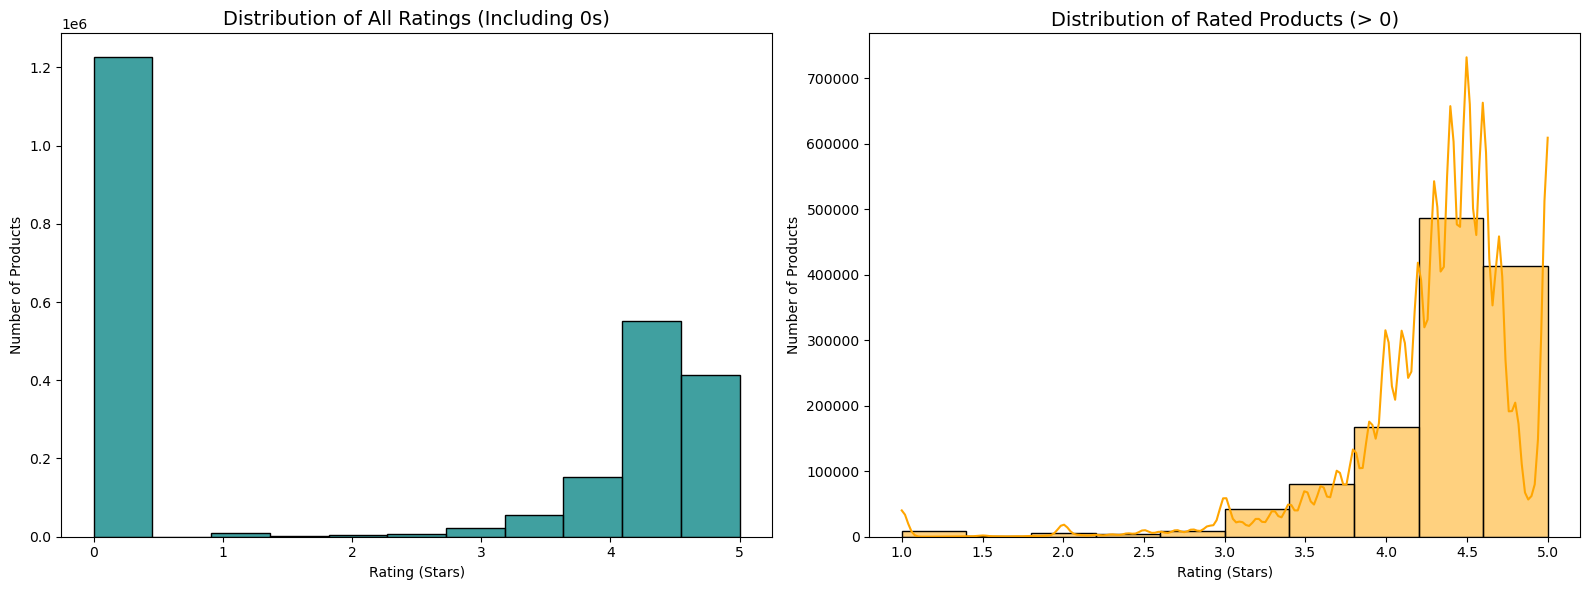

In [ ]:
plt.figure(figsize = (10,6))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6)) #fig is the variable that represents the entire window; (1, 2,) means one row and two columns; (ax1, ax2) are individual subplots, figsize=(16,6) defines the dimensions of the fig in inches.
# If plt.histplot() was used twice, then Matplotlib would either draw the second one right on top of the first one, or open two completely separate windows
# Using fig, (ax1, ax2) allows to keep "All Ratings" and "Rated Only" in one single, easy-to-compare image.
sns.histplot(df['stars'], bins = 11, kde = False, color = 'teal', ax = ax1)
ax1.set_title("Distribution of All Ratings (Including 0s)", fontsize = 14)
ax1.set_xlabel("Rating (Stars)")
ax1.set_ylabel("Number of Products")

sns.histplot(rated_products, bins = 10, kde = True, color = 'orange', ax = ax2)
ax2.set_title("Distribution of Rated Products (> 0)", fontsize = 14)
ax2.set_xlabel("Rating (Stars)")
ax2.set_ylabel("Number of Products")

plt.tight_layout()

#### Is there a specific rating that is more common?

Based on the plots and the statistics calculated, there are two common ratings depending on how we look at the data:

    Across the entire dataset: 0.0 is the most common.

        As seen in the first histogram, there is a big peak at the 0.0 mark. This represents the 50.2% of products that are unrated. From a frequency standpoint, 0.0 is the mode of the entire dataset.

    Among rated products: 4.5 is the most common.

        If we look at the second histogram (the orange one), we will see a sharp spike at the high end. This confirms the mode of 4.50. This rating is significantly more common than 1, 2, or 3 stars.

Why this is important for the Business Question?
The "most common rating" effectively tells us that Amazon UK products in this dataset tend to exist in two states: New/Unseen (0.0) or Highly Successful (4.5). The lack of products in the 1.0–3.0 range suggests that poor-quality products are either removed, not listed, or that the customer base is generally very satisfied with the "Sports & Outdoors" dominant inventory.